This notebook has code to reproduce the synthetic clustering experiment, where we try to recover patterns planted in the structure of the domain.

In [1]:
import numpy as np, pandas as pd
import itertools

from sklearn.metrics import adjusted_mutual_info_score as AMI
from scipy.spatial.distance import pdist, squareform

import matplotlib.pyplot as plt, seaborn as sns, matplotlib as mpl

from tools.core import *
from tools.clustering import *

# Similarity space

In [2]:
A = np.array(list(itertools.product(range(-5, -1, 1), range(-2, 3, 1))))
B = np.array(list(itertools.product(range(2, 6, 1), range(1, 6, 1))))
C = np.array(list(itertools.product(range(2, 6, 1), range(-1, -6, -1))))

# Embedding in R^2 with Manhattan distance
emb = np.vstack((A,B,C))
D = squareform(pdist(emb, metric='cityblock'))

# Median similarity 0.1
tau = -np.log(0.1) / np.median(D[np.triu_indices_from(D, 1)])
Z = distance_to_similarity(D, tau=tau)

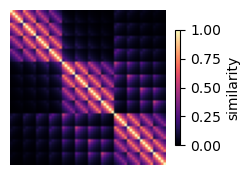

In [3]:
fig, ax = plt.subplots(1,1,figsize=(2.5, 2.5))

plt.colorbar(
    ax.imshow(Z, vmin=0, vmax=1, cmap='magma'), ax=ax, label='similarity', shrink=0.6
)
ax.set_axis_off()

# Sampling distributions

From a group, sample n_picked points with replacement and smooth with the uniform distribution.

In [4]:
block_to_start = dict(A=0, B=20, C=40)

def sample_dist_from_block(block, n_dists, n_picked, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    p = np.ones((n_dists, 60)) * 0.05 / 60.
    for i, row in enumerate( rng.choice(a=20, size=(n_dists, n_picked), replace=True) ):
        for j in row:
            p[i, block_to_start[block] + j] += 0.95 * 1.0/n_picked

    return p

In [5]:
def sample_dists(per_block, n_picked, seed=None):
    rng = np.random.default_rng(seed)
    P = []

    for block in list('ABC'):
        P.extend(sample_dist_from_block(block, per_block, n_picked, rng=rng))
    return np.array(P)

In [6]:
ground_truth_2 = [0]*10 + [1]*20
ground_truth_3 = [0]*10 + [1]*10 + [2]*10

# Experiment

In [7]:
m2result = {}
for m in [2, 4, 8, 16]:
    print(m)
    result = []
    for _ in range(50): # Number of runs (50 in the paper)
        P = sample_dists(per_block=10, n_picked=m)

        res = dict()
        cz = Clustering.from_vectors(P)
        ci = Clustering.from_vectors(P)

        # Cluster with Z
        res_z = {}
        for k in range(2,7):
            res_z[k] = cz.fit(k, Z, 2, n_trials=50, verbose=False, rel_tol=1e-8)
        res['z_curve'] = [i[2]/cz.total_information for i in res_z.values()]
        res['z_ami_2'] = AMI(res_z[2][1], ground_truth_2)
        res['z_ami_3'] = AMI(res_z[3][1], ground_truth_3)

        # Cluster with I
        res_i = {}
        for k in range(2,7):
            res_i[k] = ci.fit(k, np.eye(60), 2, n_trials=50, verbose=False, rel_tol=1e-8)
        res['i_curve'] = [i[2]/ci.total_information for i in res_i.values()]
        res['i_ami_2'] = AMI(res_i[2][1], ground_truth_2)
        res['i_ami_3'] = AMI(res_i[3][1], ground_truth_3)

        result.append(res)
    m2result[m] = result

2
4
8
16


In [ ]:
## For the results we report in the paper, load the pkl file below

# import pickle
# with open("outputs/synthetic/clustering_results.pkl", "rb") as f:
#    m2result = pickle.load(f)

Reproducing the figure in the paper.

(0.0, 1.0)

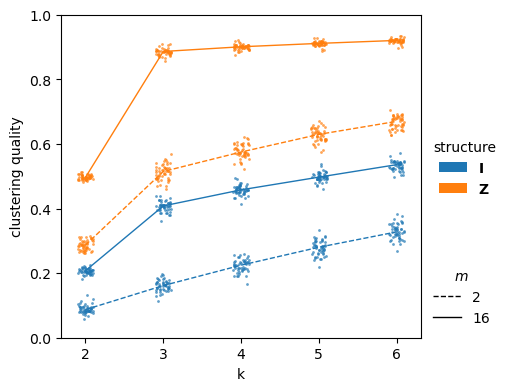

In [8]:
fig, ax = plt.subplots(1,1,figsize=(5, 3.8), layout='constrained')

sns.stripplot( np.array( [i['i_curve'] for i in m2result[2]] ), color=sns.color_palette()[0], alpha=0.7, ax=ax, s=2, marker='o')
ax.plot(
    range(5), np.median(np.array( [i['i_curve'] for i in m2result[2]] ) , axis=0), ls='--',  color=sns.color_palette()[0], lw=1
)
sns.stripplot( np.array( [i['z_curve'] for i in m2result[2]] ), color=sns.color_palette()[1], alpha=0.7, ax=ax, s=2, marker='o')
ax.plot(
    range(5), np.median(np.array( [i['z_curve'] for i in m2result[2]] ) , axis=0), ls='--',  color=sns.color_palette()[1], lw=1
)
sns.stripplot( np.array( [i['i_curve'] for i in m2result[16]] ), color=sns.color_palette()[0], alpha=0.7, ax=ax, s=2, marker='o')
ax.plot(
    range(5), np.median(np.array( [i['i_curve'] for i in m2result[16]] ) , axis=0), ls='-',  color=sns.color_palette()[0], lw=1
)
sns.stripplot( np.array( [i['z_curve'] for i in m2result[16]] ), color=sns.color_palette()[1], alpha=0.7, ax=ax, s=2, marker='o')
ax.plot(
    range(5), np.median(np.array( [i['z_curve'] for i in m2result[16]] ) , axis=0), ls='-',  color=sns.color_palette()[1], lw=1
)

legend_elements = [
    mpl.patches.Patch(facecolor=sns.color_palette()[0],  label=r'$\bf{I}$'),
    mpl.patches.Patch(facecolor=sns.color_palette()[1],  label=r'$\bf{Z}$')
]
leg = ax.legend(handles=legend_elements,loc='lower left', bbox_to_anchor=(1., 0.4),  frameon=False, title="structure")
ax.add_artist(leg)

legend_elements = [
    mpl.lines.Line2D([0], [0], color='black', lw=1, linestyle='--', label=r'2'),
    mpl.lines.Line2D([0], [0], color='black', lw=1, linestyle='-', label=r'16'),
]
ax.legend(handles=legend_elements,loc='lower left', bbox_to_anchor=(1., 0.0),  frameon=False, title=r'$m$')

ax.set_ylabel('clustering quality')
ax.set_xlabel('k')
ax.set_xticks(range(5), range(2,7))
ax.set_ylim(0, 1)

(0.0, 1.0476284574166437)

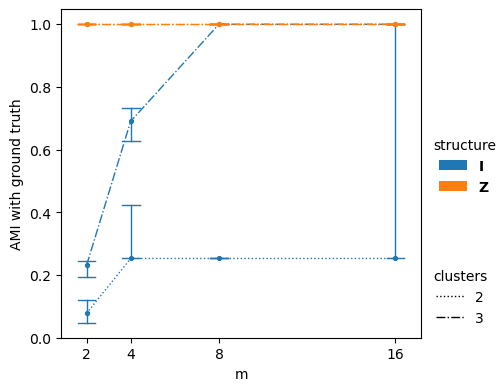

In [9]:
fig, ax = plt.subplots(1,1,figsize=(5, 3.8), layout='constrained')

sns.pointplot( {m: [i['i_ami_2'] for i in m2result[m]] for m in m2result}, color=sns.color_palette()[0], estimator='median', native_scale=True, ax=ax, ls=':',  markersize=3, lw=1, capsize=.4 )
sns.pointplot( {m: [i['i_ami_3'] for i in m2result[m]] for m in m2result}, color=sns.color_palette()[0], estimator='median', native_scale=True, ax=ax, ls='-.', markersize=3, lw=1, capsize=.4)

sns.pointplot( {m: [i['z_ami_2'] for i in m2result[m]] for m in m2result}, color=sns.color_palette()[1], estimator='median', native_scale=True, ax=ax, ls=':',  markersize=3, lw=1, capsize=.4)
sns.pointplot( {m: [i['z_ami_3'] for i in m2result[m]] for m in m2result}, color=sns.color_palette()[1], estimator='median', native_scale=True, ax=ax, ls='-.', markersize=3, lw=1, capsize=.4)


legend_elements = [
    mpl.patches.Patch(facecolor=sns.color_palette()[0],  label=r'$\bf{I}$'),
    mpl.patches.Patch(facecolor=sns.color_palette()[1],  label=r'$\bf{Z}$')
]
leg = ax.legend(handles=legend_elements,loc='lower left', bbox_to_anchor=(1., 0.4),  frameon=False, title="structure")
ax.add_artist(leg)

legend_elements = [
    mpl.lines.Line2D([0], [0], color='black', lw=1, linestyle=':', label=r'2'),
    mpl.lines.Line2D([0], [0], color='black', lw=1, linestyle='-.', label=r'3'),
]
ax.legend(handles=legend_elements,loc='lower left', bbox_to_anchor=(1., 0.0),  frameon=False, title='clusters')


ax.set_ylabel('AMI with ground truth')
ax.set_xlabel('m')
ax.set_xticks([2,4,8,16])
ax.set_ylim(0, None)